In [1]:
# pylint: disable=duplicate-code

In [2]:
# If spaCy model is missing:
# !python -m spacy download en_core_web_sm

In [3]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"


In [4]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [5]:
import sys
from pathlib import Path

# Make sure `experiments/analysis` is on sys.path, so `import src.*` works
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
analysis_dir = None  # pylint: disable=invalid-name
for p in candidates:
    if (p / "experiments" / "analysis" / "src").exists():
        analysis_dir = p / "experiments" / "analysis"
        break
    if (p / "src").exists() and p.name == "analysis":
        analysis_dir = p
        break
if analysis_dir is None:
    raise RuntimeError("Could not locate experiments/analysis directory for imports.")
sys.path.insert(0, str(analysis_dir))

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

In [7]:
from IPython.display import display
from src.common import SV_COL, get_all_modes_df, set_mode_category
from src.linguistic import ROOT_DEP, enrich, get_linguistic_stats, get_nlp, map_subwords_to_tokens
from src.multi_sentence import FIGURES_DIR, STATS_DIR, get_multi_sentence_df
from src.plots import plot_attribution_trend, plot_importance_cumsum_and_derivative, plot_token_count_distribution
from src.stats import AGG_DICT, perform_advanced_ttest
from src.transformations import calculate_normalized_entropy, normalize_lengths

# Multi-sentence analysis (SGPA=True)

This notebook mirrors the single-sentence analysis style, but is adapted for the *multi_sentence* dataset:
- prompts can span multiple user turns
- we also analyze *sentence-level* attribution (sentences ≠ turns)
- we include audio/text interaction proxies for interleaved prompts.

We only use **SGPA=True** because the SGPA=False run is missing samples for some cases.


In [8]:
df_full = get_multi_sentence_df()
df = df_full[df_full["sgpa"] == True].copy()  # noqa: E712  pylint: disable=singleton-comparison

print(df_full.groupby(["sgpa", "mode"]).size().unstack(fill_value=0))
print("rows (sgpa=True):", len(df))

mode   IAF_SM2T  ITF_SM2T  SM2T  T2T
sgpa                                
True        100       100   100   38
False       100       100    34  100
rows (sgpa=True): 338


# Data distributions


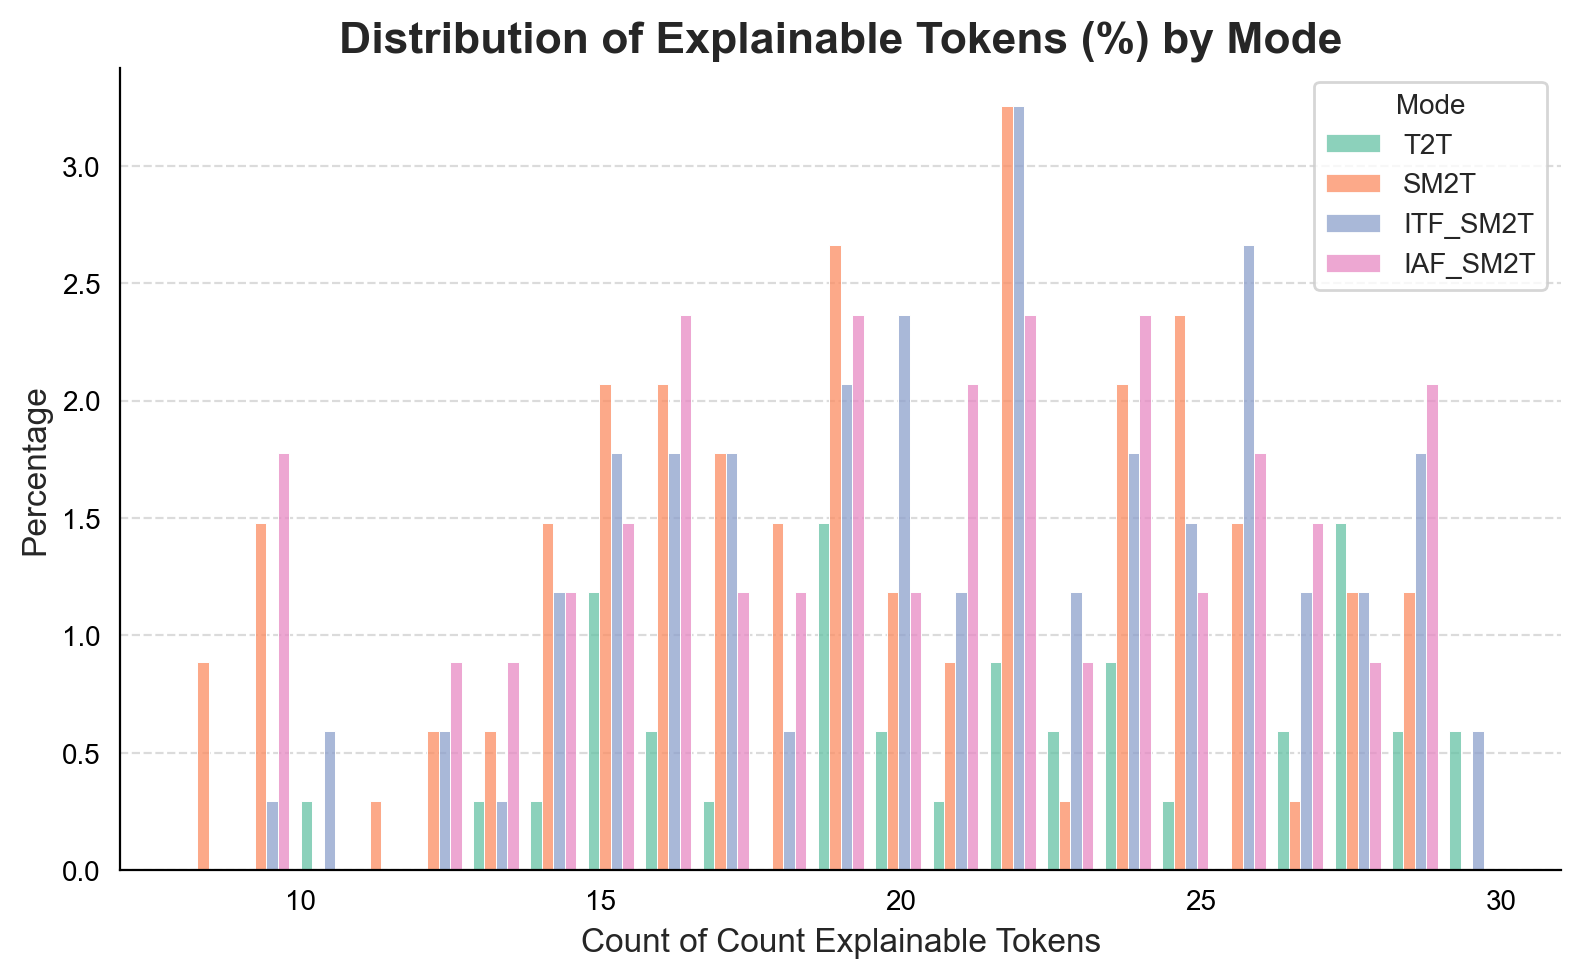

In [9]:
plot_token_count_distribution(df.rename(columns={"mode": "Mode"}), column="count_explainable_tokens", hue="Mode")
plt.savefig(f"{FIGURES_DIR}/token_count_distribution.png", bbox_inches="tight", dpi=300)

In [10]:
neyman_steps_distribution = df.groupby("mode")["neyman_steps"].value_counts(normalize=True)
neyman_steps_distribution.unstack()

neyman_steps,2
mode,
IAF_SM2T,1.0
ITF_SM2T,1.0
SM2T,1.0
T2T,1.0


In [11]:
summary_stats = df.groupby("mode")[["n_calls", "runtime_sec"]].agg(["describe"])
summary_stats.stack(level=0).unstack(level=1)

describe                                                   \
            count                     mean                     std   
          n_calls runtime_sec      n_calls runtime_sec     n_calls   
mode                                                                 
IAF_SM2T    100.0       100.0  1003.320000  384.930607  533.693834   
ITF_SM2T    100.0       100.0  1085.260000  425.544568  520.896558   
SM2T        100.0       100.0   925.960000  364.937907  513.285947   
T2T          38.0        38.0  1150.421053  402.082304  579.920434   

                                                                      \
                         min                 25%                 50%   
         runtime_sec n_calls runtime_sec n_calls runtime_sec n_calls   
mode                                                                   
IAF_SM2T  206.209165   152.0   53.373590   557.5  229.959861   991.0   
ITF_SM2T  201.316043   156.0   66.851073   629.5  258.727896  1098.0   
SM2T      199.750690   120.0   46.932554   533.5  221.536108   807.0   
T2T       187.126307   194.0   70.484976   673.5  235.953340  1105.0   

                                                              
                         75%                 max              
         runtime_sec n_calls runtime_sec n_calls runtime_sec  
mode                                                          
IAF_SM2T  350.446831  1362.5  524.962169  2010.0  840.075777  
ITF_SM2T  386.274421  1484.0  581.266058  2160.0  845.751305  
SM2T      336.990652  1331.5  491.934585  2014.0  817.372159  
T2T       396.228746  1719.0  554.843868  2164.0  828.346159

In [12]:
# Quick sanity: show a few prompts/responses
for pt, rmr in df[df["mode"] == "T2T"][["inputs", "raw_model_response"]].head(3).itertuples(index=False):
    print(pt)
    print("\t- " + str(rmr).replace("\n", "\\n"))

My friend's dog just died and they are really sadHow do I comfort them
	- <|im_start|>assistant\nI'm really sorry to hear about your friend's loss. It's completely natural to feel sad and overwhelmed after a pet dies. Here are some ways<|im_end|>\n
Write a detailed review of the movie "The Social Network".Your entire response should be in English and all lower case (no capital letters whatsoever).
	- <|im_start|>assistant\nthe social network is a gripping and thought-provoking film that delves into the complexities of the tech industry and the personal sacrifices made by<|im_end|>\n
On the basis of the subject of the email determine whether the email should be treated as spam or notDermatologists do not like her
	- <|im_start|>assistant\nThe subject line "Dermatologists do not like her!" suggests that the dermatologist is dissatisfied with her. However, the email itself does<|im_end|>\n


# Linguistic enrichment (token-level)
We compute spaCy token stats on the full concatenated prompt text (English).


In [13]:
df["linguistic_stats"] = df["inputs"].apply(lambda s: get_linguistic_stats(s, language="en"))
df["stats_mapping"] = df.apply(
    lambda row: map_subwords_to_tokens(
        row["tokens"],
        [stat["text"] for stat in row["linguistic_stats"]],
        language="en",
    ),
    axis=1,
)
if not (df["stats_mapping"].apply(len) == df["tokens"].apply(len)).all().item():
    raise RuntimeError("Subword to token mapping length mismatch.")
results_df = enrich(df)
results_df.head(2)

,prompt,row_index,mode,language,token,id,sv,dep,pos,children,importance,group
0,My friend's dog just died and they are really ...,25,T2T,en,My,0,0.047189,poss,PRON,0,4.0,modifiers
1,My friend's dog just died and they are really ...,25,T2T,en,friend,1,0.088149,poss,NOUN,2,4.0,modifiers


In [14]:
# Convenience columns
results_df["abs_sv"] = results_df[SV_COL].abs()
results_df["is_audio"] = results_df["token"].astype(str).str.contains(r"AUDIO_", regex=True)
results_df["is_text"] = ~results_df["is_audio"]
text_results_df = results_df[results_df["is_text"]].copy()
text_results_df.shape

(3018, 15)

In [15]:
# Aggregate-mode flags (same idea as single_sentence)
additional_modes = ["S2S", "S2T", "S2*", "T2*", "*2T", "*2S"]
modes_order = ["ALL", "T2*", "S2*", "*2T", "*2S", "T2T", "SM2T", "ITF_SM2T", "IAF_SM2T"]

results_df["T2*"] = results_df["mode"] == "T2T"
results_df["S2T"] = results_df["mode"].isin(["SM2T", "ITF_SM2T", "IAF_SM2T"])
results_df["S2S"] = False
results_df["S2*"] = results_df["S2T"] | results_df["S2S"]
results_df["*2T"] = results_df["T2*"] | results_df["S2T"]
results_df["*2S"] = False

all_modes_results_df = get_all_modes_df(results_df, additional_modes=additional_modes)
all_modes_results_df = set_mode_category(all_modes_results_df, modes_order)

# Base tests (multimodality focus)


In [27]:
def filter_results(_df: pd.DataFrame) -> pd.DataFrame:
    """Keep only significant adjusted p-values and core columns."""
    if _df is None or _df.empty:
        return pd.DataFrame()
    cols = [
        "metric",
        "Mode_1",
        "Mode_2",
        "P_Value",
        "Significant_Adj",
        "Shapiro_Significant",
        "Cohens_dz",
    ]
    cols = [c for c in cols if c in _df.columns]
    # out = _df[_df["Significant_Adj"]].copy()
    return _df[cols].sort_values(by=["metric", "Mode_1", "Mode_2"]).reset_index(drop=True)

In [34]:
results = perform_advanced_ttest(
    results_df,
    grp_by_cols=["row_index", "mode"],
    value_col=SV_COL,
)
results.to_csv(f"{STATS_DIR}/mean_ttest_results.csv", index=False)
results = filter_results(results)
results[results["Shapiro_Significant"]]

,metric,Mode_1,Mode_2,P_Value,Significant_Adj,Shapiro_Significant,Cohens_dz
0,entropy,IAF_SM2T,ITF_SM2T,0.9,False,True,-0.01
1,entropy,IAF_SM2T,SM2T,0.81,False,True,0.02
3,entropy,ITF_SM2T,SM2T,0.76,False,True,0.03
13,max,IAF_SM2T,SM2T,0.24,False,True,-0.12
15,max,ITF_SM2T,SM2T,0.15,False,True,-0.15
16,max,ITF_SM2T,T2T,0.32,False,True,0.17
18,mean,IAF_SM2T,ITF_SM2T,<0.01,True,True,0.34
19,mean,IAF_SM2T,SM2T,<0.01,True,True,-0.48
20,mean,IAF_SM2T,T2T,<0.01,True,True,0.88
21,mean,ITF_SM2T,SM2T,<0.01,True,True,-0.49


## Entropy (token-level SV spread)


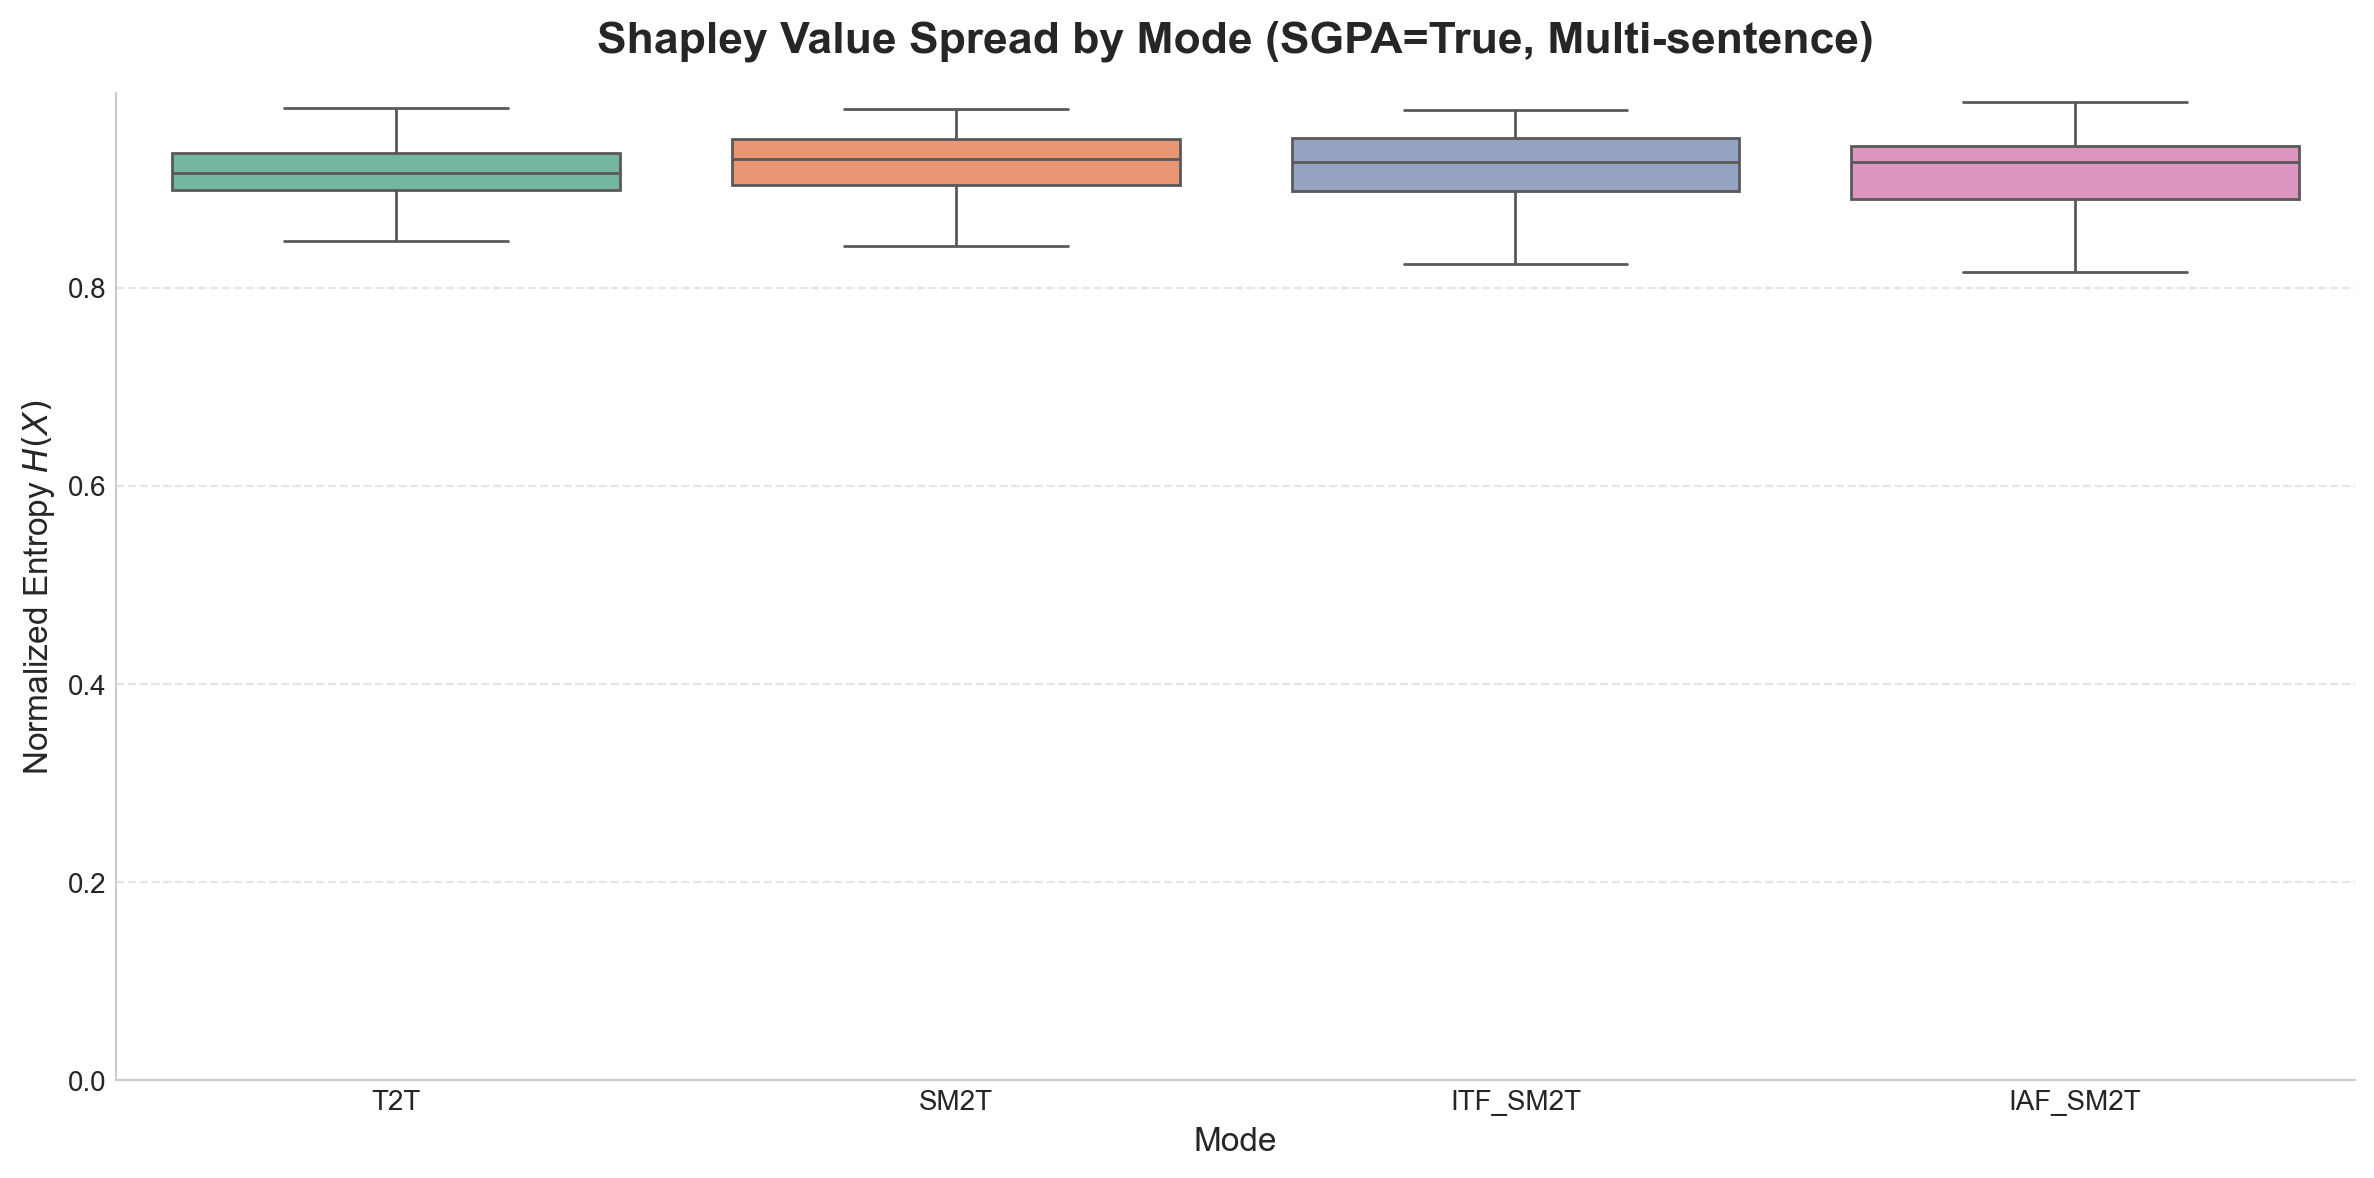

In [18]:
df["sv_entropy"] = df["sv"].apply(calculate_normalized_entropy)
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df, x="mode", y="sv_entropy", palette="Set2", showfliers=False)
plt.title("Shapley Value Spread by Mode (SGPA=True, Multi-sentence)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Mode", fontsize=12)
plt.ylabel("Normalized Entropy $H(X)$", fontsize=12)
plt.ylim(bottom=0)
sns.despine(top=True, right=True)
ax.tick_params(axis="both", which="both", length=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sv_entropy_by_mode.png", bbox_inches="tight", dpi=300)

## Over time / positional bias (token position)


In [19]:
pos_df = df[["row_index", "mode", "sv"]].copy()
pos_df = pos_df.explode("sv").reset_index(drop=True)
pos_df["sv"] = pos_df["sv"].astype(float)
pos_df["token_pos_idx"] = pos_df.groupby(["mode", "row_index"]).cumcount()
pos_df["max_idx"] = pos_df.groupby(["mode", "row_index"])["token_pos_idx"].transform("max")
pos_df.loc[pos_df["max_idx"] == 0, "max_idx"] = 1
pos_df["normalized_position"] = pos_df["token_pos_idx"] / pos_df["max_idx"]

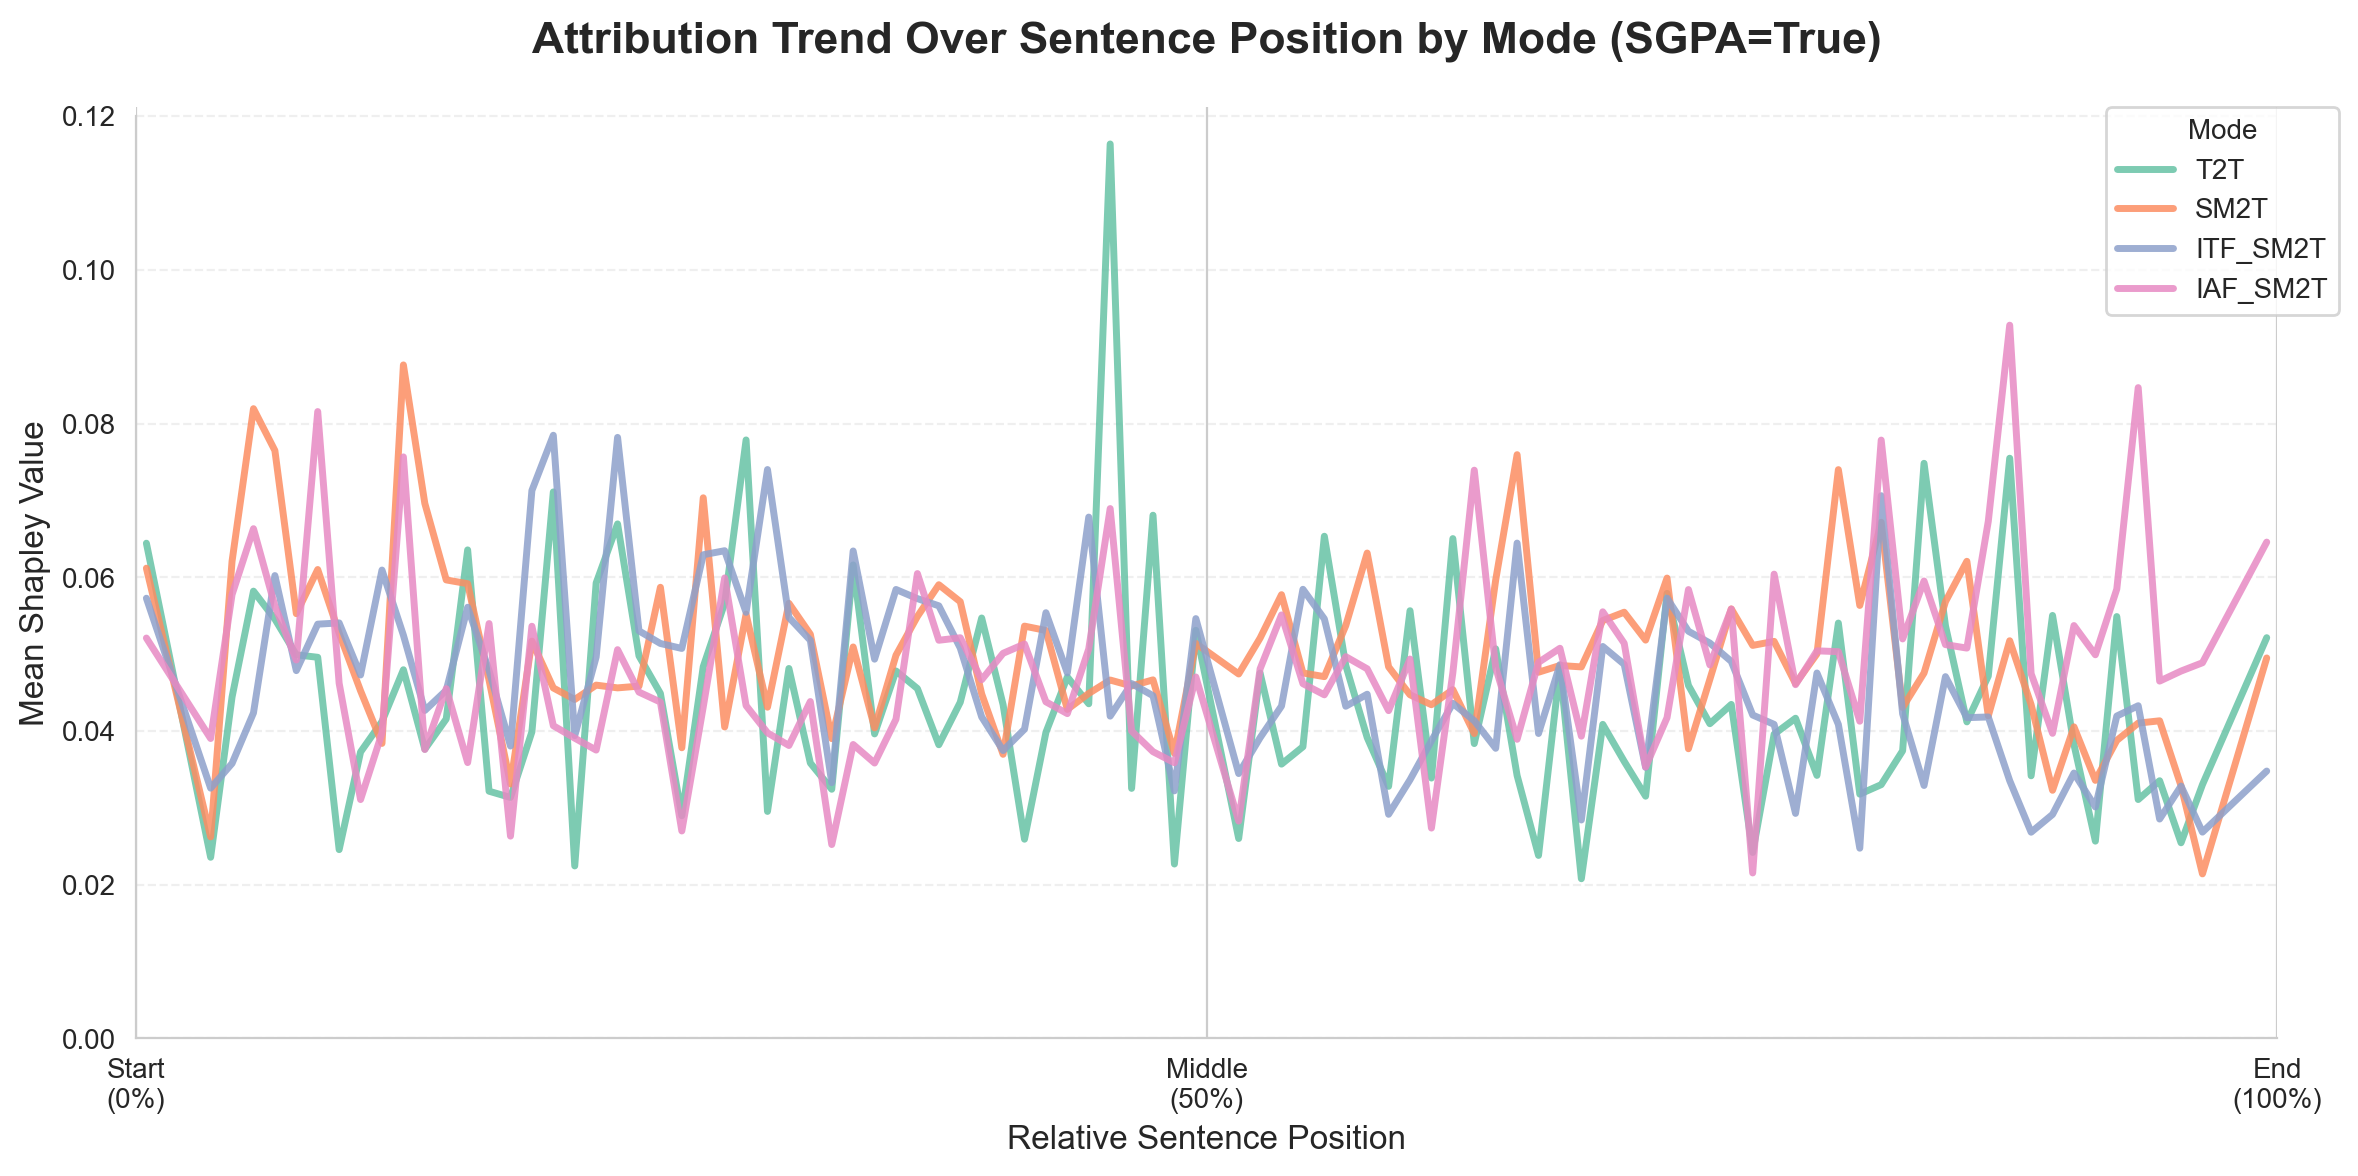

In [20]:
plot_attribution_trend(pos_df, n_bins=100, legend=True, suffix=" (SGPA=True)")
plt.savefig(f"{FIGURES_DIR}/positional_bias.png", bbox_inches="tight", dpi=300)

## Cumulative sum + derivative


In [21]:
df["sv_cumsum"] = df[SV_COL].apply(np.cumsum)
cumsums = df.groupby(["mode", "row_index"], group_keys=False)[["mode", "row_index", "sv_cumsum"]].apply(
    normalize_lengths
)
plot_df = cumsums.explode("sv_cumsum").reset_index(drop=True)
plot_df["time (tokens)"] = plot_df.groupby(["mode", "row_index"]).cumcount()
plot_df["sv_cumsum"] = plot_df["sv_cumsum"].astype(float)
plot_df["sv_derivative"] = plot_df.groupby(["mode", "row_index"])["sv_cumsum"].diff().fillna(0)

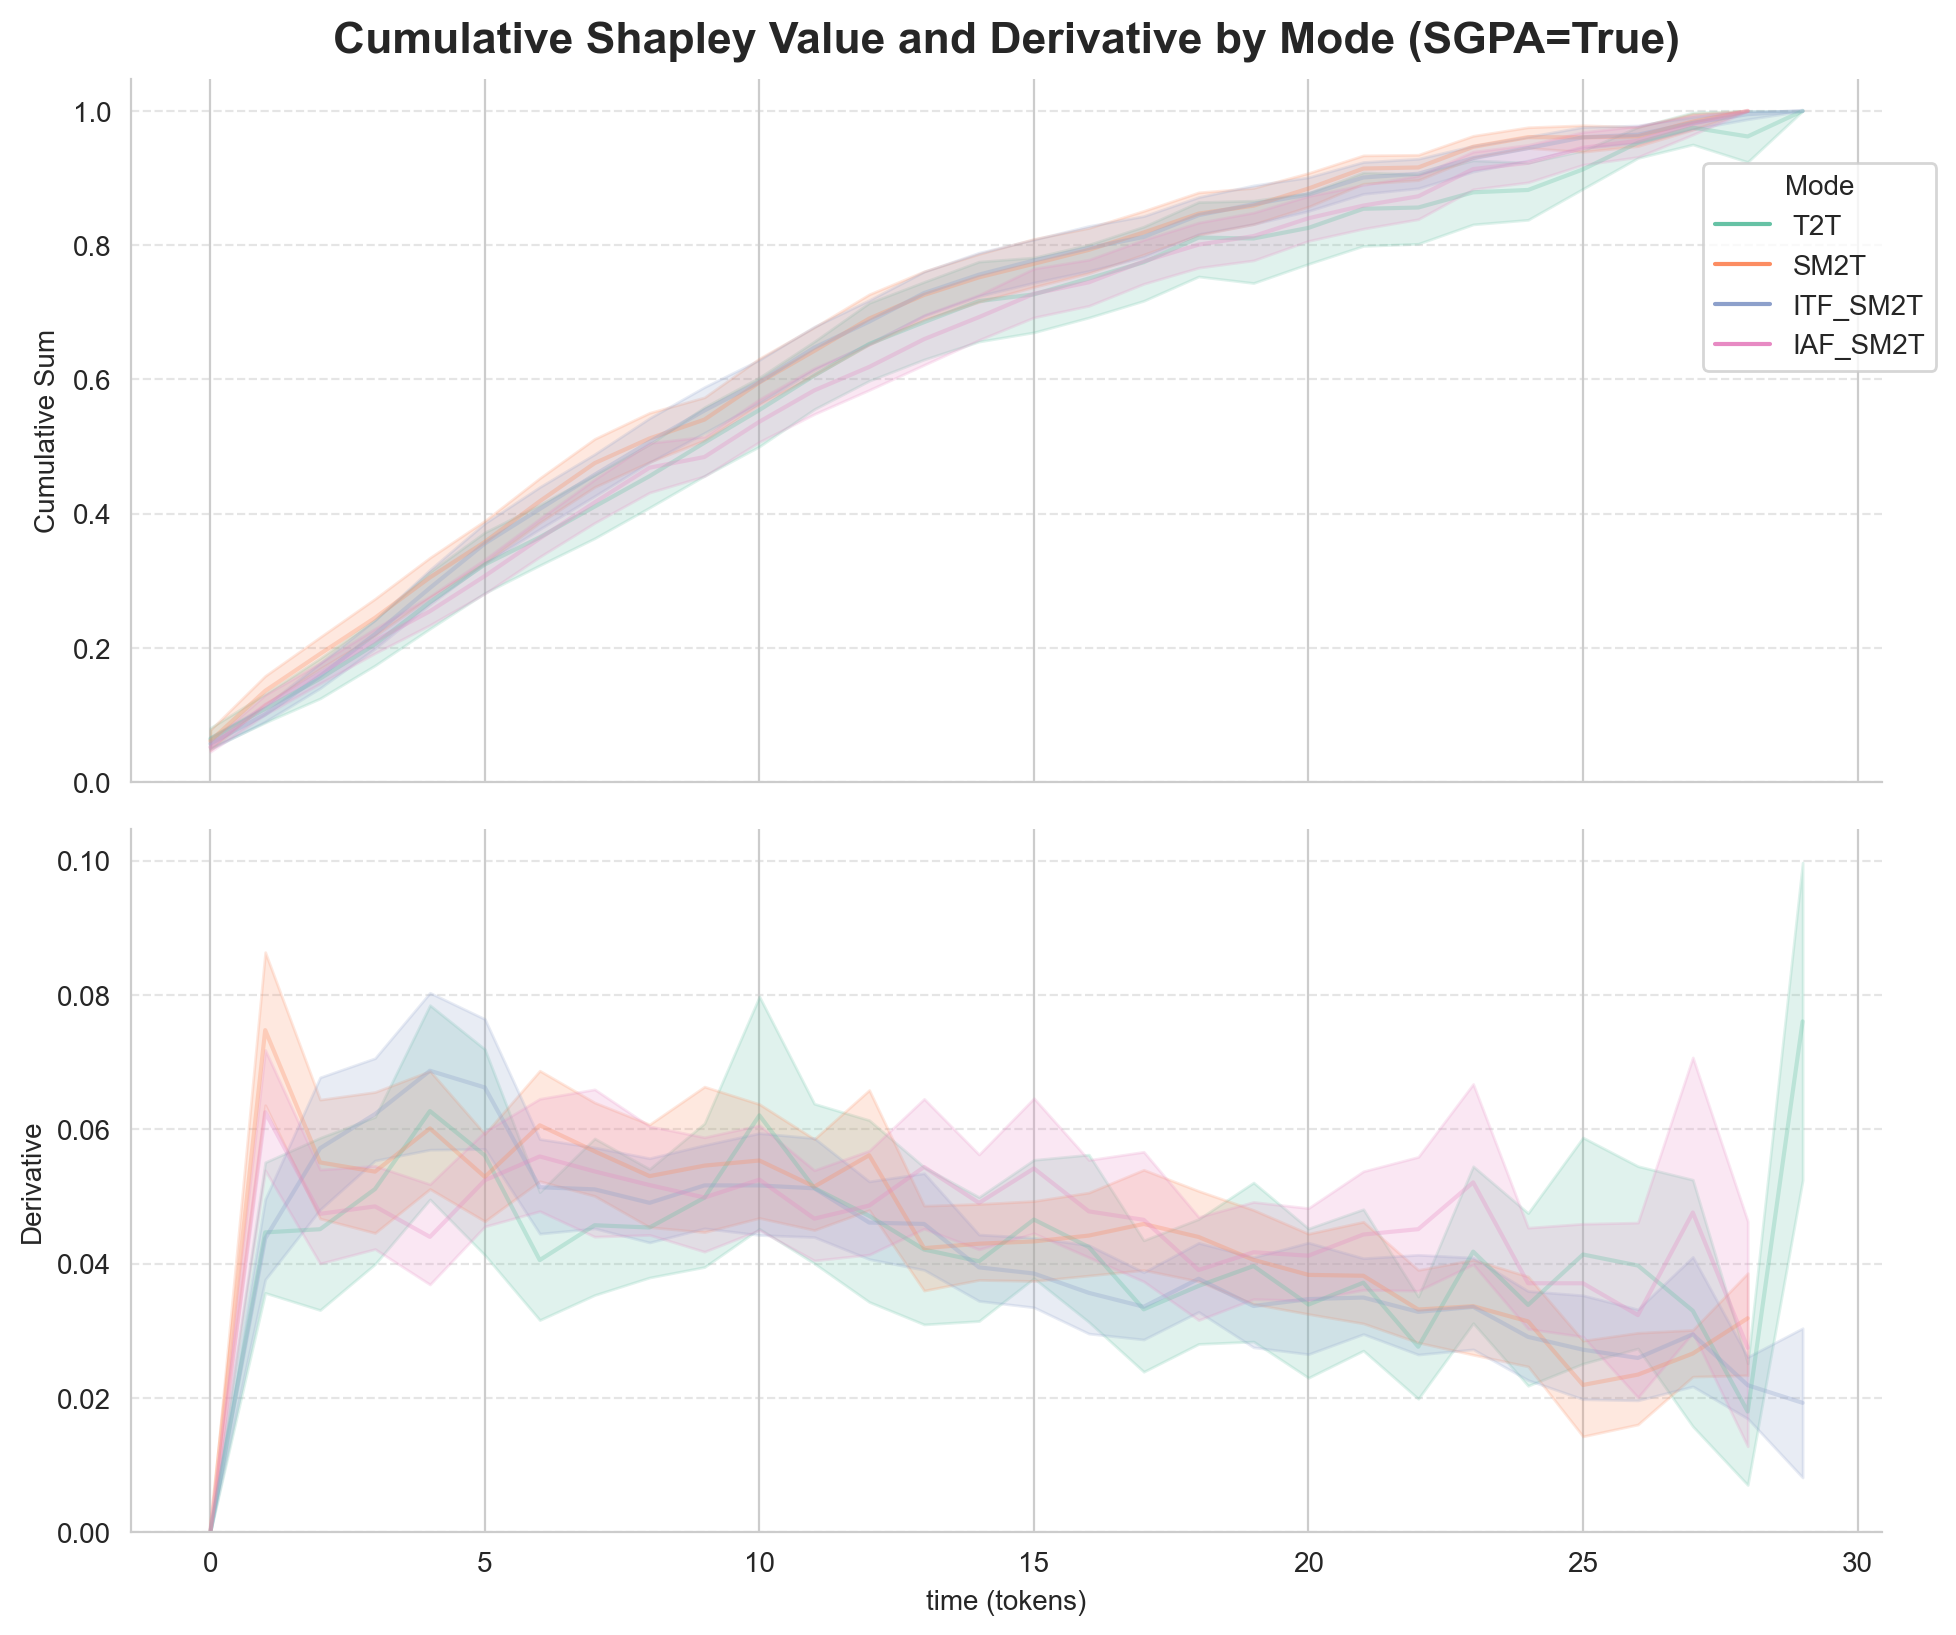

In [22]:
plot_importance_cumsum_and_derivative(plot_df)
plt.title("Cumulative Shapley Value and Derivative by Mode (SGPA=True)", fontsize=16, fontweight="bold", pad=280)
plt.savefig(f"{FIGURES_DIR}/cumulative_shapley_and_derivative.png", bbox_inches="tight", dpi=300)

# Linguistic analyses (text tokens only)


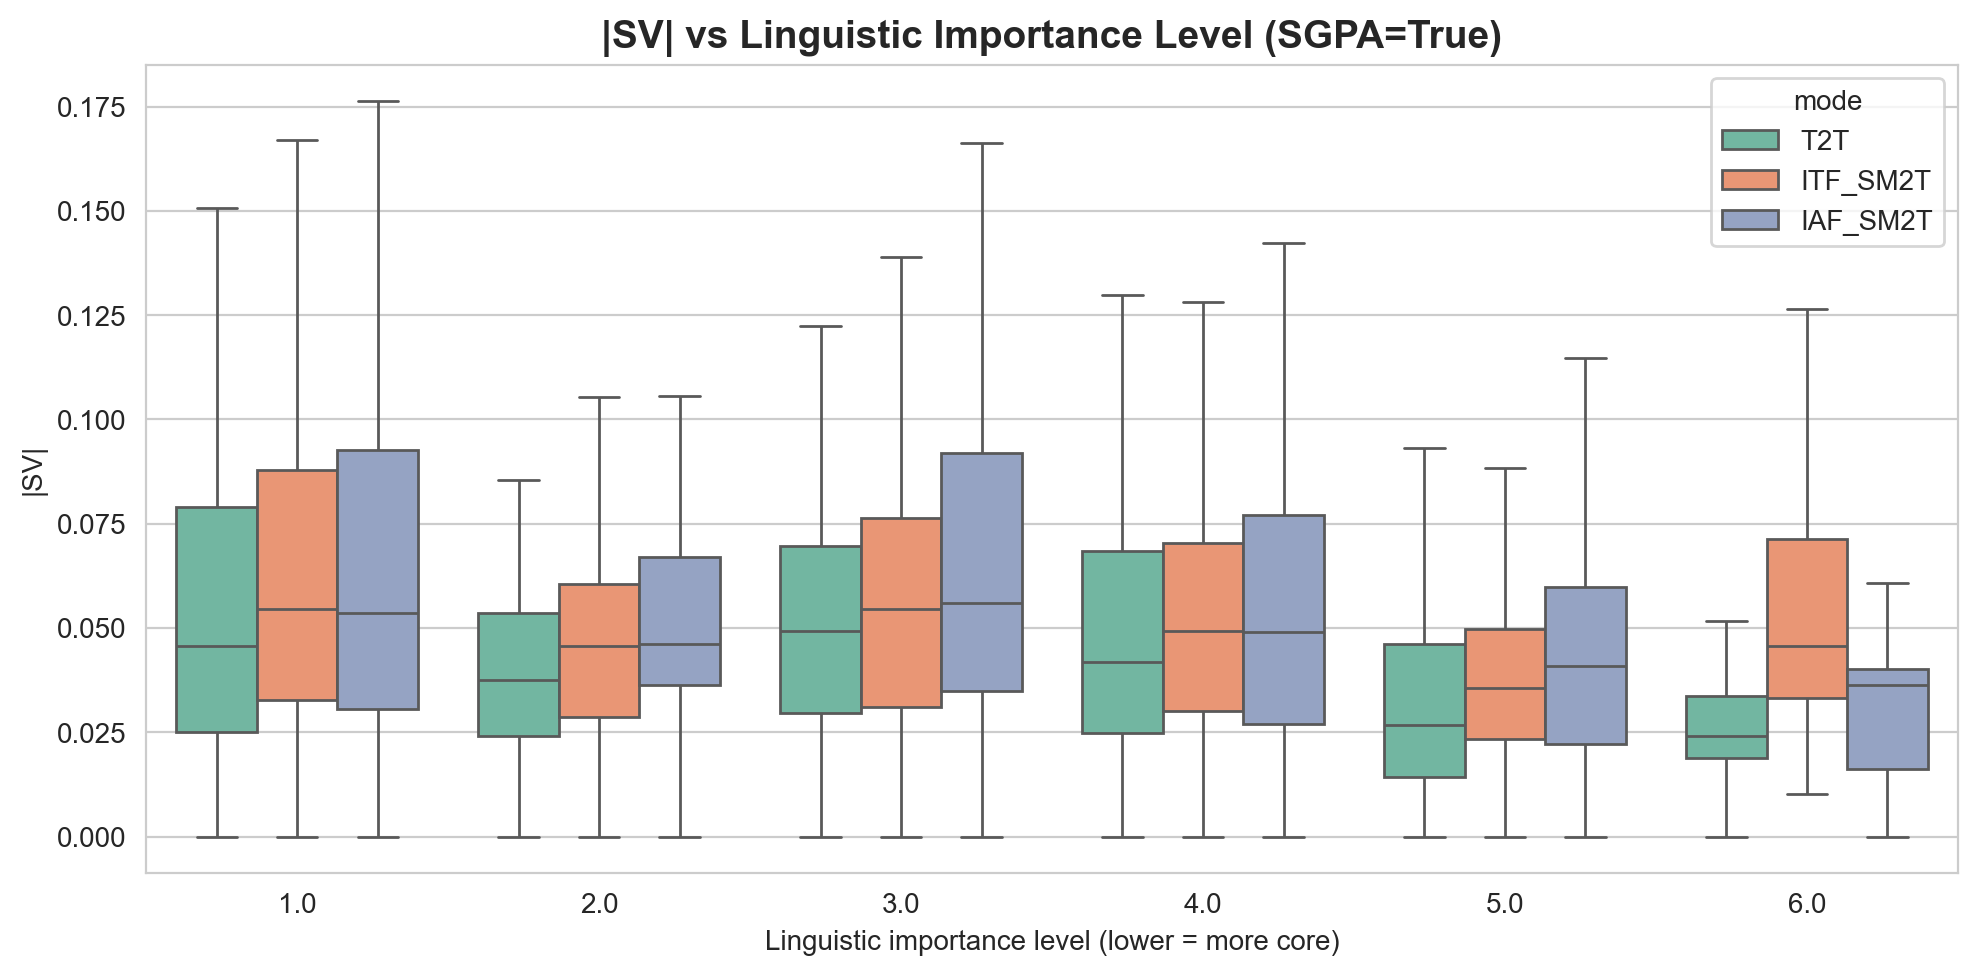

In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=text_results_df.dropna(subset=["importance"]),
    x="importance",
    y="abs_sv",
    hue="mode",
    showfliers=False,
    palette="Set2",
)
plt.title("|SV| vs Linguistic Importance Level (SGPA=True)", fontsize=14, fontweight="bold")
plt.xlabel("Linguistic importance level (lower = more core)")
plt.ylabel("|SV|")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/abs_sv_vs_linguistic_importance.png", bbox_inches="tight", dpi=300)

In [24]:
importance_stats = text_results_df.dropna(subset=["importance"]).groupby(["mode", "importance"])[SV_COL].agg(**AGG_DICT)
importance_stats.to_csv(f"{STATS_DIR}/importance_stats.csv")
importance_stats

mean      gini  top_20_mass       max   entropy
mode     importance                                                     
IAF_SM2T 1.0         0.069768  0.422612     0.468251  0.364470  0.943801
         2.0         0.048860  0.283592     0.349751  0.105549  0.952149
         3.0         0.068461  0.377361     0.429912  0.286802  0.948046
         4.0         0.055376  0.394738     0.429633  0.236149  0.949617
         5.0         0.047048  0.399571     0.440788  0.279147  0.946457
         6.0         0.030815  0.391283     0.456248  0.080351  0.897819
ITF_SM2T 1.0         0.065188  0.386286     0.432481  0.398443  0.955634
         2.0         0.050857  0.350092     0.421535  0.183844  0.949115
         3.0         0.058911  0.358239     0.404067  0.213830  0.956693
         4.0         0.054648  0.368629     0.413153  0.366648  0.955659
         5.0         0.038960  0.326772     0.386257  0.155273  0.967601
         6.0         0.058561  0.330118     0.423196  0.199007  0.950058
T2T      1.0         0.057155  0.427978     0.465221  0.256114  0.940359
         2.0         0.042278  0.357037     0.417700  0.146811  0.943349
         3.0         0.051193  0.329106     0.380923  0.149056  0.960573
         4.0         0.050554  0.399467     0.436822  0.264407  0.947576
         5.0         0.032599  0.405352     0.433988  0.155536  0.947469
         6.0         0.032458  0.392518     0.532900  0.116063  0.876377

In [25]:
pos_stats = text_results_df.dropna(subset=["pos"]).groupby(["mode", "pos"])[SV_COL].agg(**AGG_DICT)
pos_stats.to_csv(f"{STATS_DIR}/pos_stats.csv")
top_pos = text_results_df["pos"].value_counts().head(12).index.tolist()
pos_stats.loc[(slice(None), top_pos), :].head(10)

,,mean,gini,top_20_mass,max,entropy
mode,pos,,,,,
IAF_SM2T,NOUN,0.071678,0.395751,0.442347,0.286802,0.949069
ITF_SM2T,NOUN,0.069686,0.356837,0.416461,0.366648,0.961617
T2T,NOUN,0.056829,0.355268,0.415052,0.226226,0.959286
IAF_SM2T,VERB,0.069378,0.377887,0.436985,0.364470,0.947073
ITF_SM2T,VERB,0.058142,0.346737,0.413742,0.398443,0.956505
T2T,VERB,0.054807,0.434700,0.476979,0.264407,0.932024
IAF_SM2T,ADP,0.044730,0.356085,0.406339,0.138335,0.946883
ITF_SM2T,ADP,0.042426,0.325046,0.380033,0.145268,0.961283
T2T,ADP,0.032419,0.398407,0.440844,0.126515,0.938106


In [26]:
def match_rate_max_abs_sv_equals_max_children(_df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-mode match rate between argmax(|SV|) and argmax(children)."""
    rows: list[dict] = []
    for (row_index, mode), grp in _df.groupby(["row_index", "mode"], sort=False):
        grp = grp.dropna(subset=["children"]).copy()
        grp = grp[(grp["dep"] != ROOT_DEP) & (grp["pos"] != "PUNCT")]
        if grp.empty:
            continue
        max_sv_row = grp.loc[grp["abs_sv"].idxmax()]
        max_children_row = grp.loc[grp["children"].idxmax()]
        rows.append({"row_index": row_index, "mode": mode, "match": int(max_sv_row["id"] == max_children_row["id"])})
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.groupby("mode")["match"].agg(match_rate="mean", n="size").reset_index()


children_match = match_rate_max_abs_sv_equals_max_children(text_results_df)
children_match.to_csv(f"{STATS_DIR}/match_max_abs_sv_equals_max_children.csv", index=False)
children_match

,mode,match_rate,n
0,IAF_SM2T,0.262626,99
1,ITF_SM2T,0.161616,99
2,T2T,0.131579,38


In [27]:
def ttests_by_category(
    token_df: pd.DataFrame,
    category_col: str,
    out_csv: str,
    categories: list[str] | None = None,
) -> pd.DataFrame:
    """Run advanced t-tests per category and persist results."""
    token_df = token_df.dropna(subset=[category_col]).copy()
    if categories is None:
        categories = sorted(token_df[category_col].unique().tolist())
    results_list = []
    for cat in categories:
        subset = token_df[token_df[category_col] == cat]
        if subset.empty:
            continue
        r = perform_advanced_ttest(subset, grp_by_cols=["row_index", "mode"], value_col=SV_COL, unstack=["mode"])
        r[category_col] = cat
        results_list.append(r)
    if not results_list:
        return pd.DataFrame()
    out = pd.concat(results_list, ignore_index=True)
    out.to_csv(out_csv, index=False)
    return out


group_ttests = ttests_by_category(text_results_df, category_col="group", out_csv=f"{STATS_DIR}/ttest_by_group.csv")
pos_ttests = ttests_by_category(
    text_results_df, category_col="pos", out_csv=f"{STATS_DIR}/ttest_by_pos.csv", categories=top_pos
)
display(group_ttests[group_ttests["Significant_Adj"]].head(15))
display(pos_ttests[pos_ttests["Significant_Adj"]].head(15))

,Mode_1,Mode_2,T_Statistic,P_Value,Degrees_of_Freedom,Sample_Size,Mean_Diff,Kurtosis_Diff,Shapiro_P,Cohens_dz,Significant_Adj,Shapiro_Significant,metric,group,index
3,IAF_SM2T,ITF_SM2T,-2.530327,0.01,51.0,52.0,-0.079835,-0.596642,0.159549,-0.35,True,False,gini,arguments,NaN
4,IAF_SM2T,T2T,-4.471598,<0.01,21.0,22.0,-0.162600,-1.022743,0.468662,-0.95,True,False,gini,arguments,NaN
7,IAF_SM2T,T2T,5.593501,<0.01,21.0,22.0,0.300925,0.280706,0.148623,1.19,True,False,top_20_mass,arguments,NaN
8,ITF_SM2T,T2T,3.245433,<0.01,29.0,30.0,0.149395,-0.353698,0.226775,0.59,True,False,top_20_mass,arguments,NaN
13,IAF_SM2T,T2T,-4.000702,<0.01,21.0,22.0,-0.458363,0.014749,0.004801,-0.85,True,True,entropy,arguments,NaN
30,IAF_SM2T,T2T,3.660683,0.01,8.0,9.0,0.014337,-0.519643,0.609492,1.22,True,False,mean,coordination,NaN
42,ITF_SM2T,T2T,4.641138,<0.01,37.0,38.0,0.016283,0.582044,0.031682,0.75,True,True,mean,core_structure,NaN
44,IAF_SM2T,T2T,-2.575850,0.01,34.0,35.0,-0.095234,-0.751204,0.349608,-0.44,True,False,gini,core_structure,NaN
45,ITF_SM2T,T2T,-3.133002,<0.01,37.0,38.0,-0.095493,1.008241,0.051690,-0.51,True,False,gini,core_structure,NaN
46,IAF_SM2T,ITF_SM2T,4.516519,<0.01,93.0,94.0,0.130226,-0.497107,0.203874,0.47,True,False,top_20_mass,core_structure,NaN


,Mode_1,Mode_2,T_Statistic,P_Value,Degrees_of_Freedom,Sample_Size,Mean_Diff,Kurtosis_Diff,Shapiro_P,Cohens_dz,Significant_Adj,Shapiro_Significant,metric,pos
2,ITF_SM2T,T2T,3.898381,<0.01,36,37,0.019805,-0.140027,0.308404,0.64,True,False,mean,NOUN
3,IAF_SM2T,ITF_SM2T,-3.022266,<0.01,79,80,-0.068002,-0.007624,0.064735,-0.34,True,False,gini,NOUN
4,IAF_SM2T,T2T,-3.915597,<0.01,31,32,-0.132961,0.417376,0.136504,-0.69,True,False,gini,NOUN
5,ITF_SM2T,T2T,-2.688558,0.01,36,37,-0.063972,0.278927,0.243745,-0.44,True,False,gini,NOUN
6,IAF_SM2T,ITF_SM2T,4.475787,<0.01,79,80,0.184993,0.055682,0.046094,0.50,True,True,top_20_mass,NOUN
7,IAF_SM2T,T2T,3.442866,<0.01,31,32,0.177754,0.441177,0.055914,0.61,True,False,top_20_mass,NOUN
12,IAF_SM2T,ITF_SM2T,-4.906461,<0.01,79,80,-0.301407,-0.796027,0.000004,-0.55,True,True,entropy,NOUN
13,IAF_SM2T,T2T,-3.872714,<0.01,31,32,-0.301677,-1.395792,0.000163,-0.68,True,True,entropy,NOUN
19,IAF_SM2T,T2T,-4.451056,<0.01,21,22,-0.169745,-1.149588,0.115385,-0.95,True,False,gini,VERB
20,ITF_SM2T,T2T,-5.725703,<0.01,30,31,-0.163482,-0.585432,0.790915,-1.03,True,False,gini,VERB


# Multi-sentence specific analyses (sentences ≠ turns)


In [28]:
nlp_en = get_nlp("en")
docs = list(nlp_en.pipe(df["inputs"].tolist(), batch_size=32))

spacy_sentence_ids = []
for doc in docs:
    sent_ids = np.zeros(len(doc), dtype=int)
    for sid, sent in enumerate(doc.sents):
        for tok in sent:
            sent_ids[tok.i] = sid
    spacy_sentence_ids.append(sent_ids.tolist())

df["spacy_sentence_ids"] = spacy_sentence_ids
df["subword_sentence_id"] = df.apply(lambda row: [row["spacy_sentence_ids"][i] for i in row["stats_mapping"]], axis=1)

sent_map = df[["row_index", "mode", "subword_sentence_id"]].explode("subword_sentence_id").reset_index(drop=True)
sent_map["id"] = sent_map.groupby(["row_index", "mode"]).cumcount()
sent_map = sent_map.rename(columns={"subword_sentence_id": "sentence_id"})

results_df_sent = results_df.merge(sent_map, on=["row_index", "mode", "id"], how="left")
if results_df_sent["sentence_id"].isna().any():
    raise RuntimeError("Missing sentence_id for some token rows.")
results_df_sent["abs_sv"] = results_df_sent[SV_COL].abs()
results_df_sent.head(2)

,prompt,row_index,mode,language,token,id,sv,dep,pos,children,...,abs_sv,is_audio,is_text,T2*,S2T,S2S,S2*,*2T,*2S,sentence_id
0,My friend's dog just died and they are really ...,25,T2T,en,My,0,0.047189,poss,PRON,0,...,0.047189,False,True,True,False,False,False,True,False,0
1,My friend's dog just died and they are really ...,25,T2T,en,friend,1,0.088149,poss,NOUN,2,...,0.088149,False,True,True,False,False,False,True,False,0


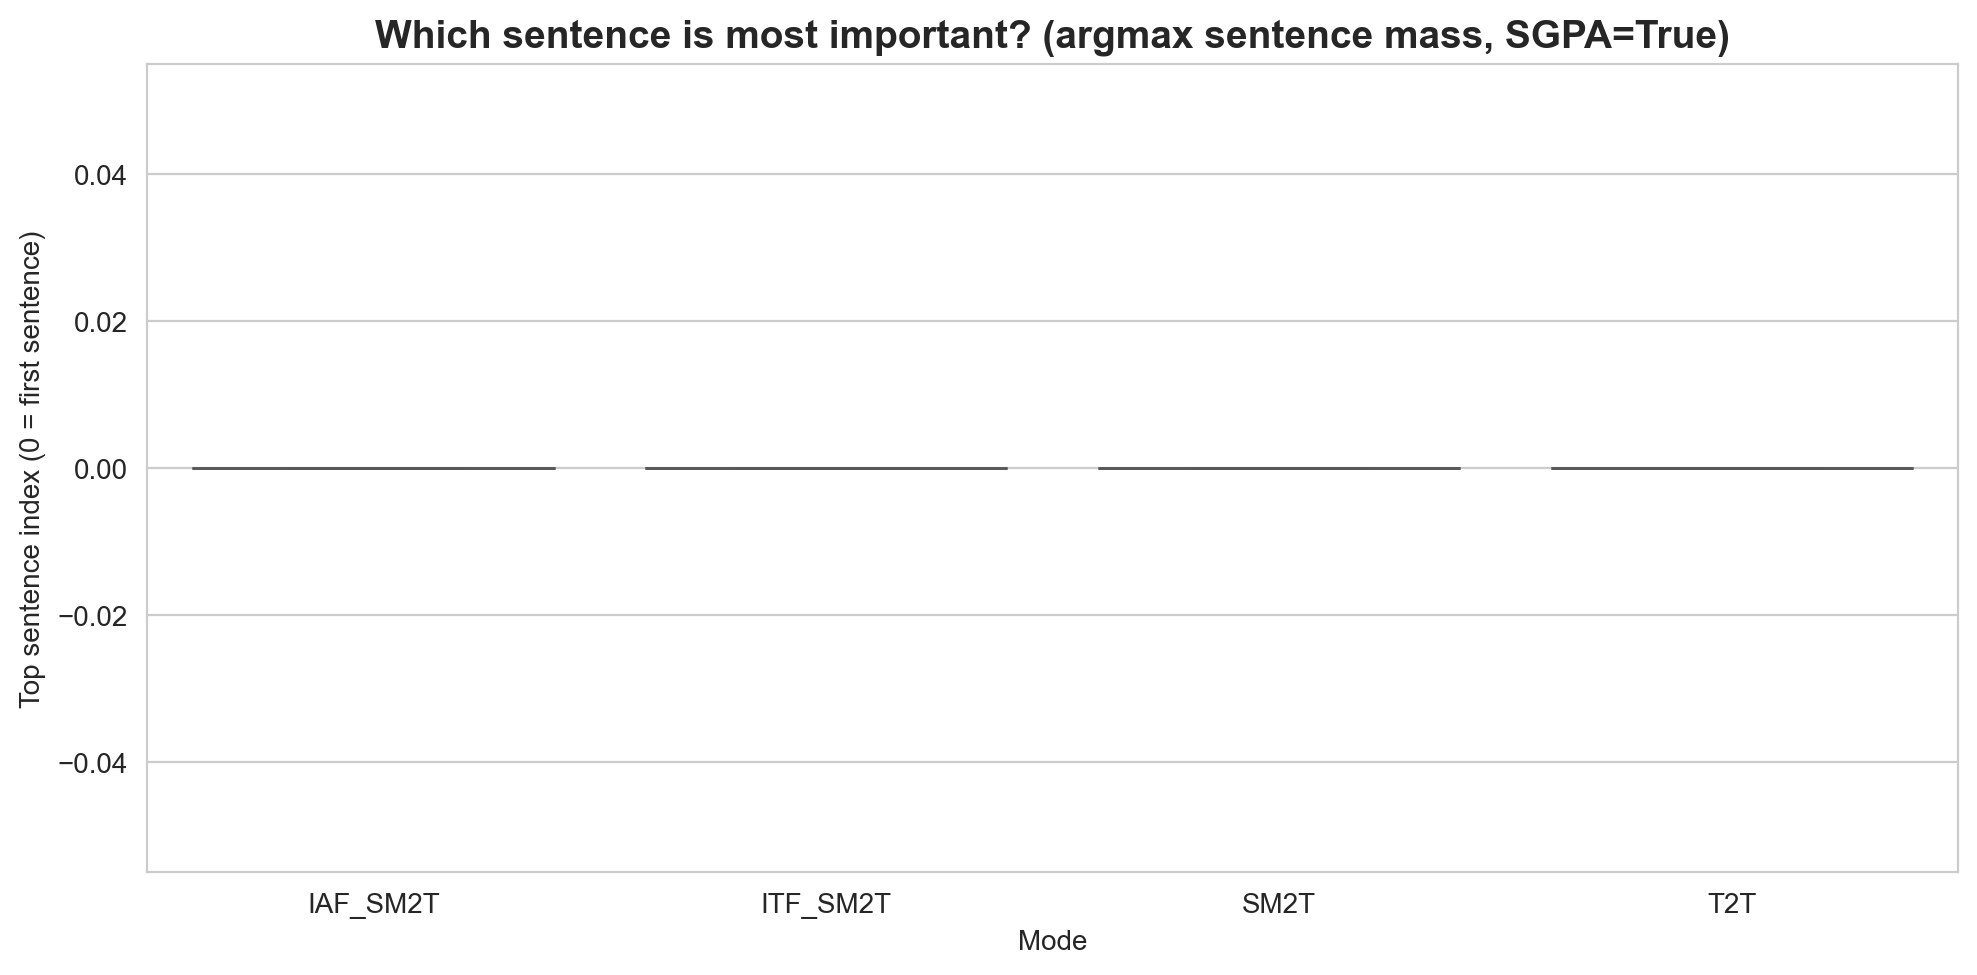

In [29]:
sent_mass = (
    results_df_sent.groupby(["row_index", "mode", "sentence_id"], as_index=False)["abs_sv"]
    .sum()
    .rename(columns={"abs_sv": "sent_abs_mass"})
)
sent_mass["total_abs_mass"] = sent_mass.groupby(["row_index", "mode"])["sent_abs_mass"].transform("sum")
sent_mass["sent_share"] = sent_mass["sent_abs_mass"] / sent_mass["total_abs_mass"].replace(0, np.nan)

top_sent = (
    sent_mass.sort_values(["row_index", "mode", "sent_share"], ascending=[True, True, False])
    .groupby(["row_index", "mode"], as_index=False)
    .head(1)
)
top_sent = top_sent.rename(columns={"sentence_id": "top_sentence_id", "sent_share": "top_sentence_share"})
top_sent.to_csv(f"{STATS_DIR}/top_sentence_by_mass.csv", index=False)

plt.figure(figsize=(10, 5))
sns.boxplot(data=top_sent, x="mode", y="top_sentence_id", showfliers=False, palette="Set2")
plt.title("Which sentence is most important? (argmax sentence mass, SGPA=True)", fontsize=14, fontweight="bold")
plt.xlabel("Mode")
plt.ylabel("Top sentence index (0 = first sentence)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/top_sentence_index_by_mode.png", bbox_inches="tight", dpi=300)

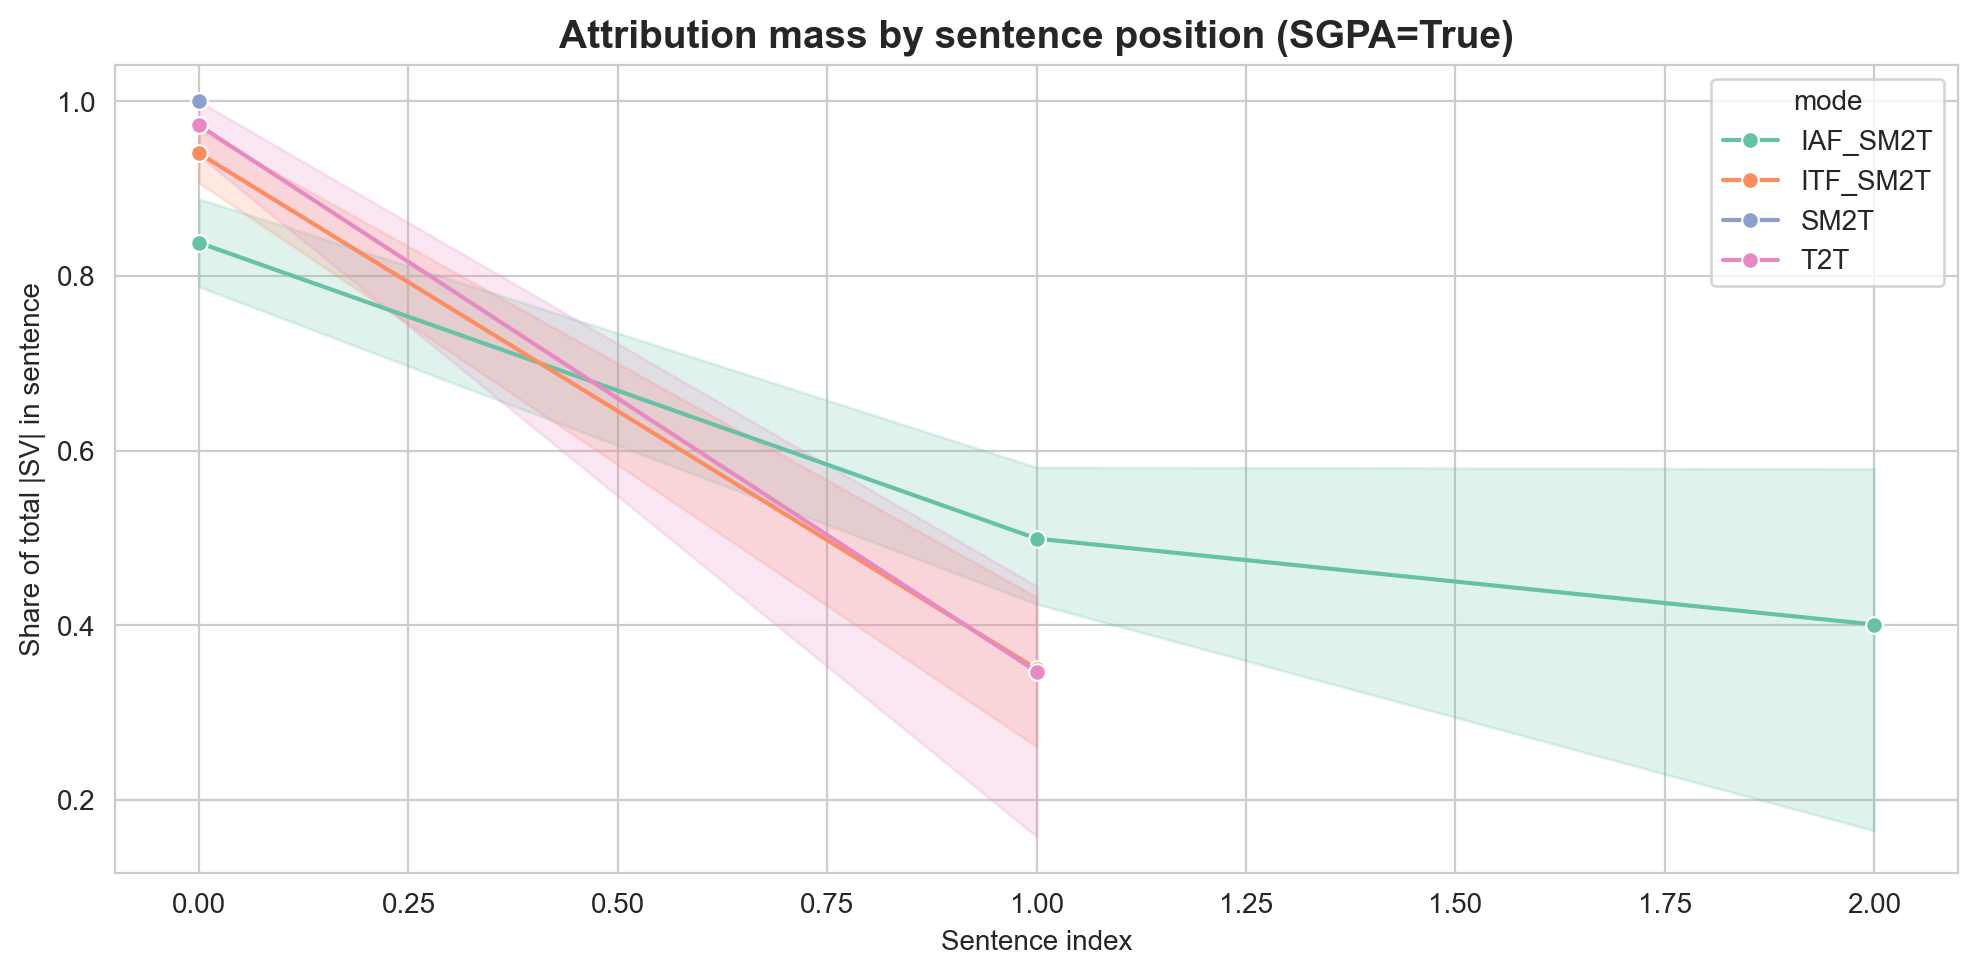

In [30]:
MAX_SENTENCES_TO_SHOW = 10
sent_bias = sent_mass[sent_mass["sentence_id"] < MAX_SENTENCES_TO_SHOW].copy()
sent_bias = sent_bias.rename(columns={"sentence_id": "sentence_idx"})

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=sent_bias, x="sentence_idx", y="sent_share", hue="mode", errorbar=("ci", 95), marker="o", palette="Set2"
)
plt.title("Attribution mass by sentence position (SGPA=True)", fontsize=14, fontweight="bold")
plt.xlabel("Sentence index")
plt.ylabel("Share of total |SV| in sentence")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sentence_position_bias.png", bbox_inches="tight", dpi=300)

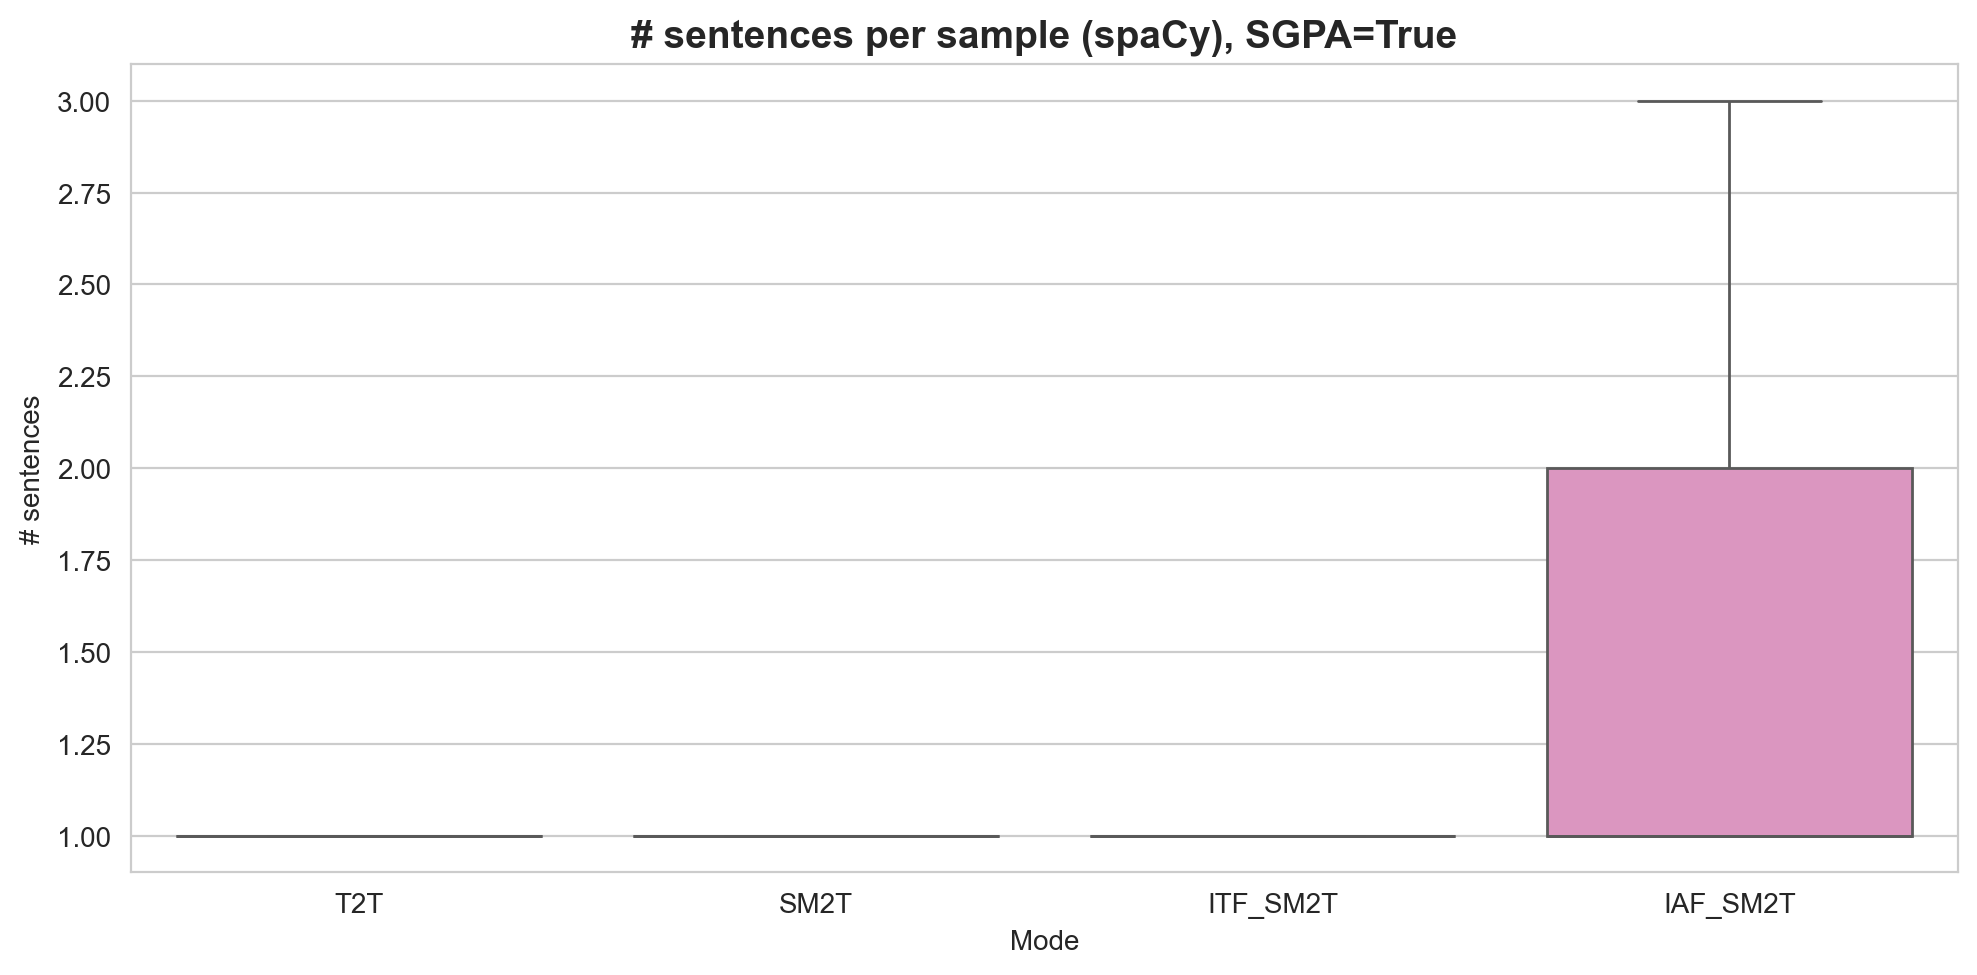

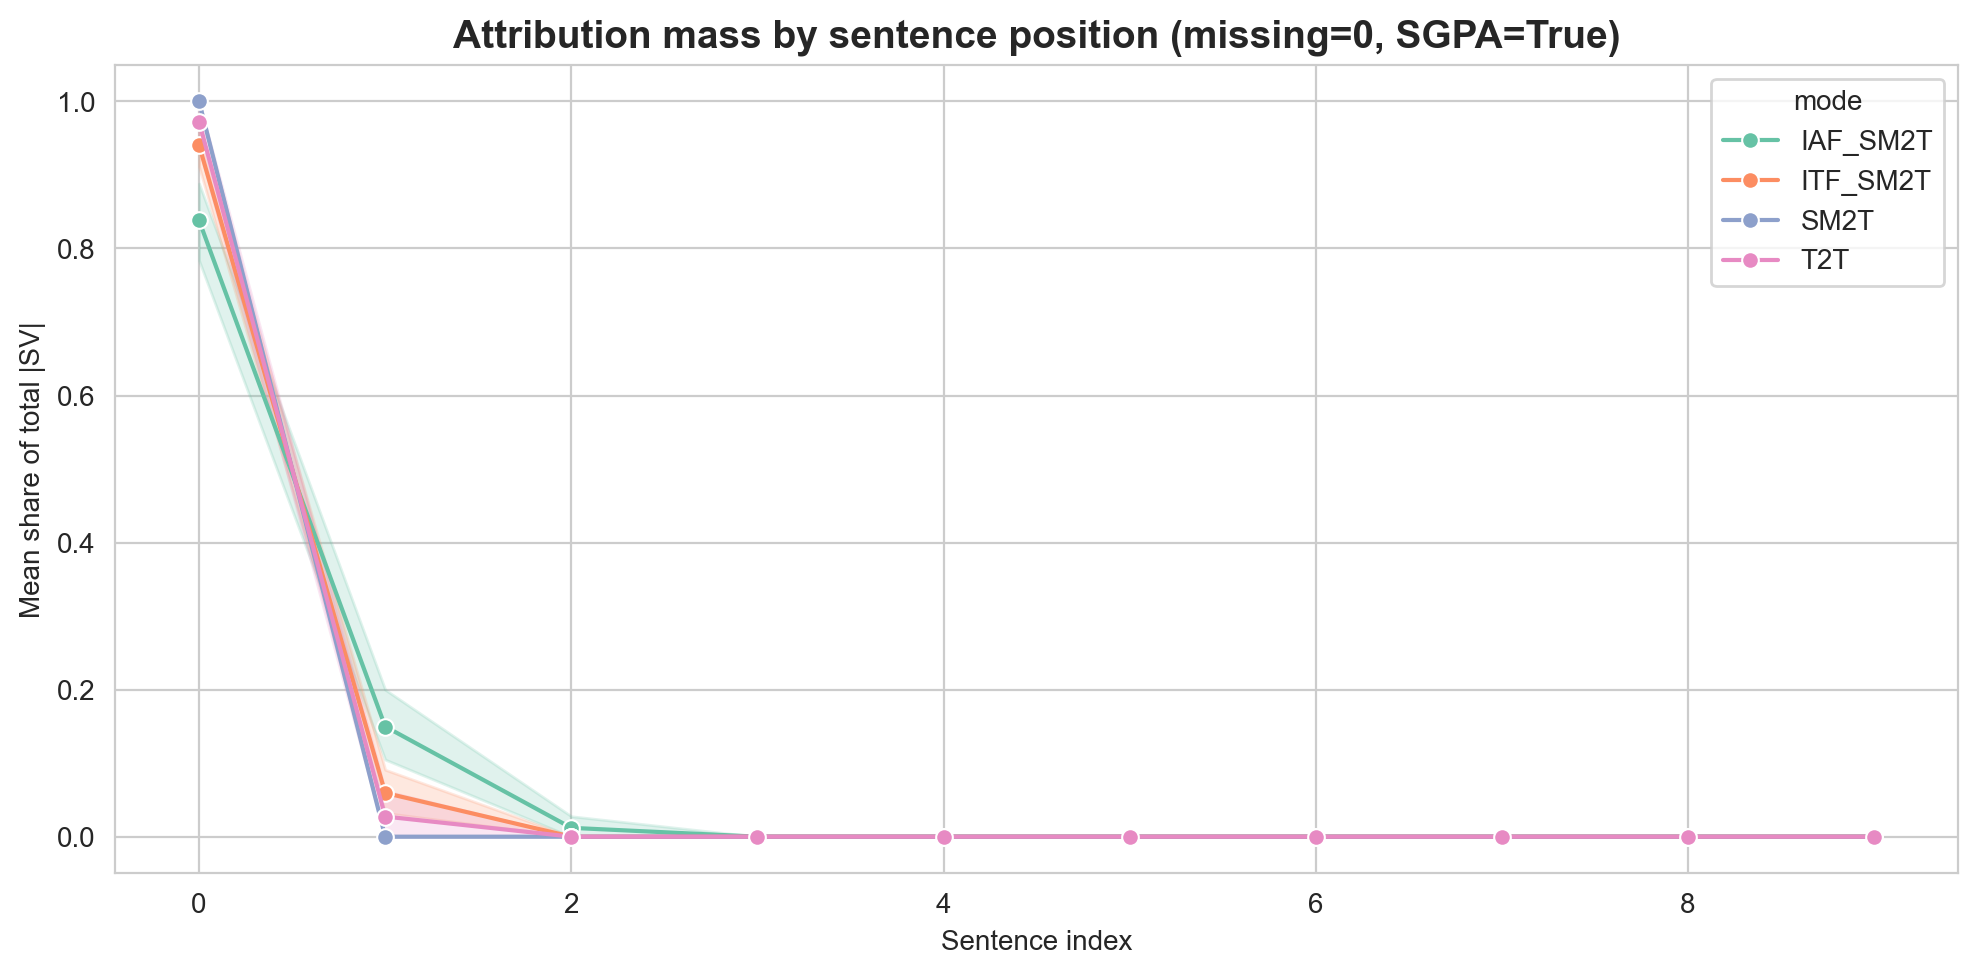

In [31]:
df["n_sentences"] = df["spacy_sentence_ids"].apply(
    lambda ids: int(max(ids) + 1) if isinstance(ids, list) and len(ids) else 0
)
sentence_counts = df[["row_index", "mode", "n_sentences"]].copy()
sentence_counts.to_csv(f"{STATS_DIR}/n_sentences_by_sample.csv", index=False)

plt.figure(figsize=(10, 5))
sns.boxplot(data=sentence_counts, x="mode", y="n_sentences", showfliers=False, palette="Set2")
plt.title("# sentences per sample (spaCy), SGPA=True", fontsize=14, fontweight="bold")
plt.xlabel("Mode")
plt.ylabel("# sentences")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/n_sentences_by_mode.png", bbox_inches="tight", dpi=300)

sent_pivot = sent_mass.pivot_table(
    index=["row_index", "mode"], columns="sentence_id", values="sent_share", aggfunc="first"
)
sent_pivot = sent_pivot.reindex(columns=list(range(MAX_SENTENCES_TO_SHOW)), fill_value=0).fillna(0)
sent_pivot = sent_pivot.reset_index().melt(
    id_vars=["row_index", "mode"], var_name="sentence_idx", value_name="sent_share"
)
sent_pivot["sentence_idx"] = sent_pivot["sentence_idx"].astype(int)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=sent_pivot, x="sentence_idx", y="sent_share", hue="mode", errorbar=("ci", 95), marker="o", palette="Set2"
)
plt.title("Attribution mass by sentence position (missing=0, SGPA=True)", fontsize=14, fontweight="bold")
plt.xlabel("Sentence index")
plt.ylabel("Mean share of total |SV|")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sentence_position_bias_missing0.png", bbox_inches="tight", dpi=300)

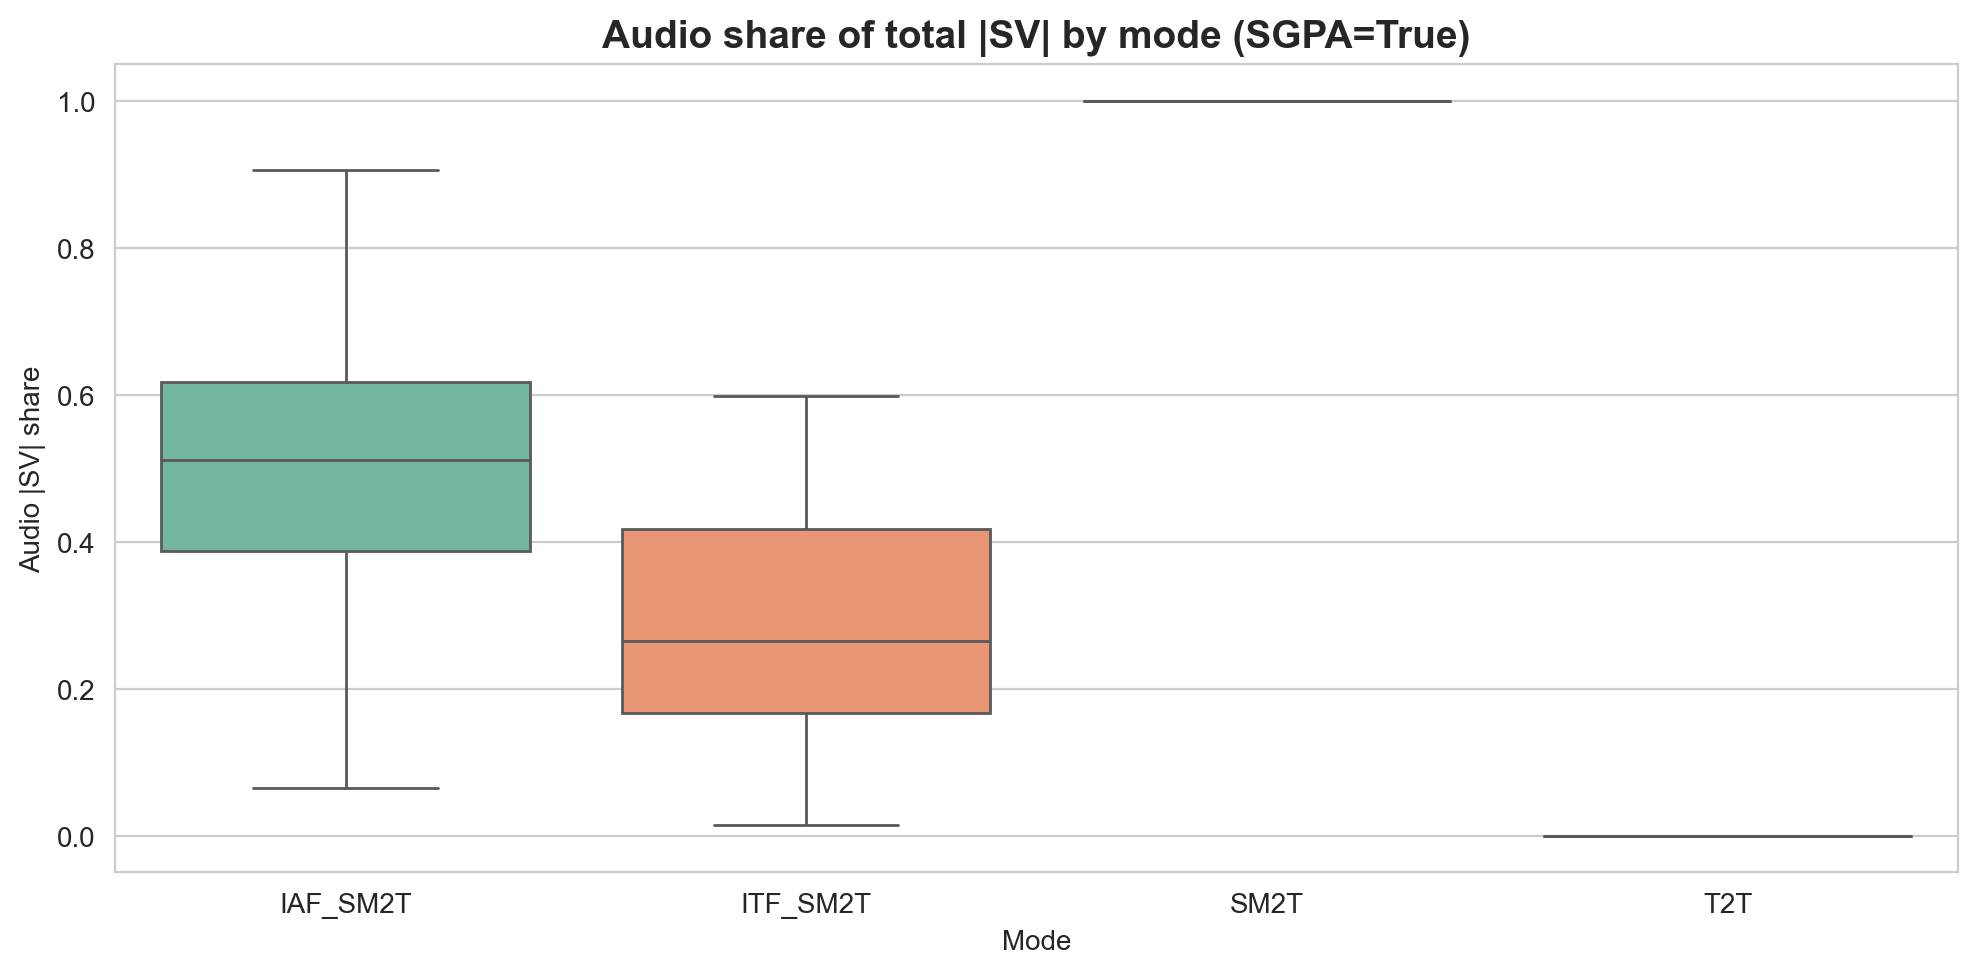

In [32]:
results_df_sent["is_audio"] = results_df_sent["token"].astype(str).str.contains(r"AUDIO_", regex=True)
results_df_sent["is_text"] = ~results_df_sent["is_audio"]

audio_share = (
    results_df_sent.groupby(["row_index", "mode"], as_index=False)
    .apply(
        lambda g: pd.Series(
            {
                "audio_abs_mass": g.loc[g["is_audio"], "abs_sv"].sum(),
                "text_abs_mass": g.loc[g["is_text"], "abs_sv"].sum(),
                "total_abs_mass": g["abs_sv"].sum(),
            }
        )
    )
    .reset_index(drop=True)
)
audio_share["audio_share"] = audio_share["audio_abs_mass"] / audio_share["total_abs_mass"].replace(0, np.nan)
audio_share.to_csv(f"{STATS_DIR}/audio_share_by_sample.csv", index=False)

plt.figure(figsize=(10, 5))
sns.boxplot(data=audio_share, x="mode", y="audio_share", showfliers=False, palette="Set2")
plt.title("Audio share of total |SV| by mode (SGPA=True)", fontsize=14, fontweight="bold")
plt.xlabel("Mode")
plt.ylabel("Audio |SV| share")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/audio_share_by_mode.png", bbox_inches="tight", dpi=300)

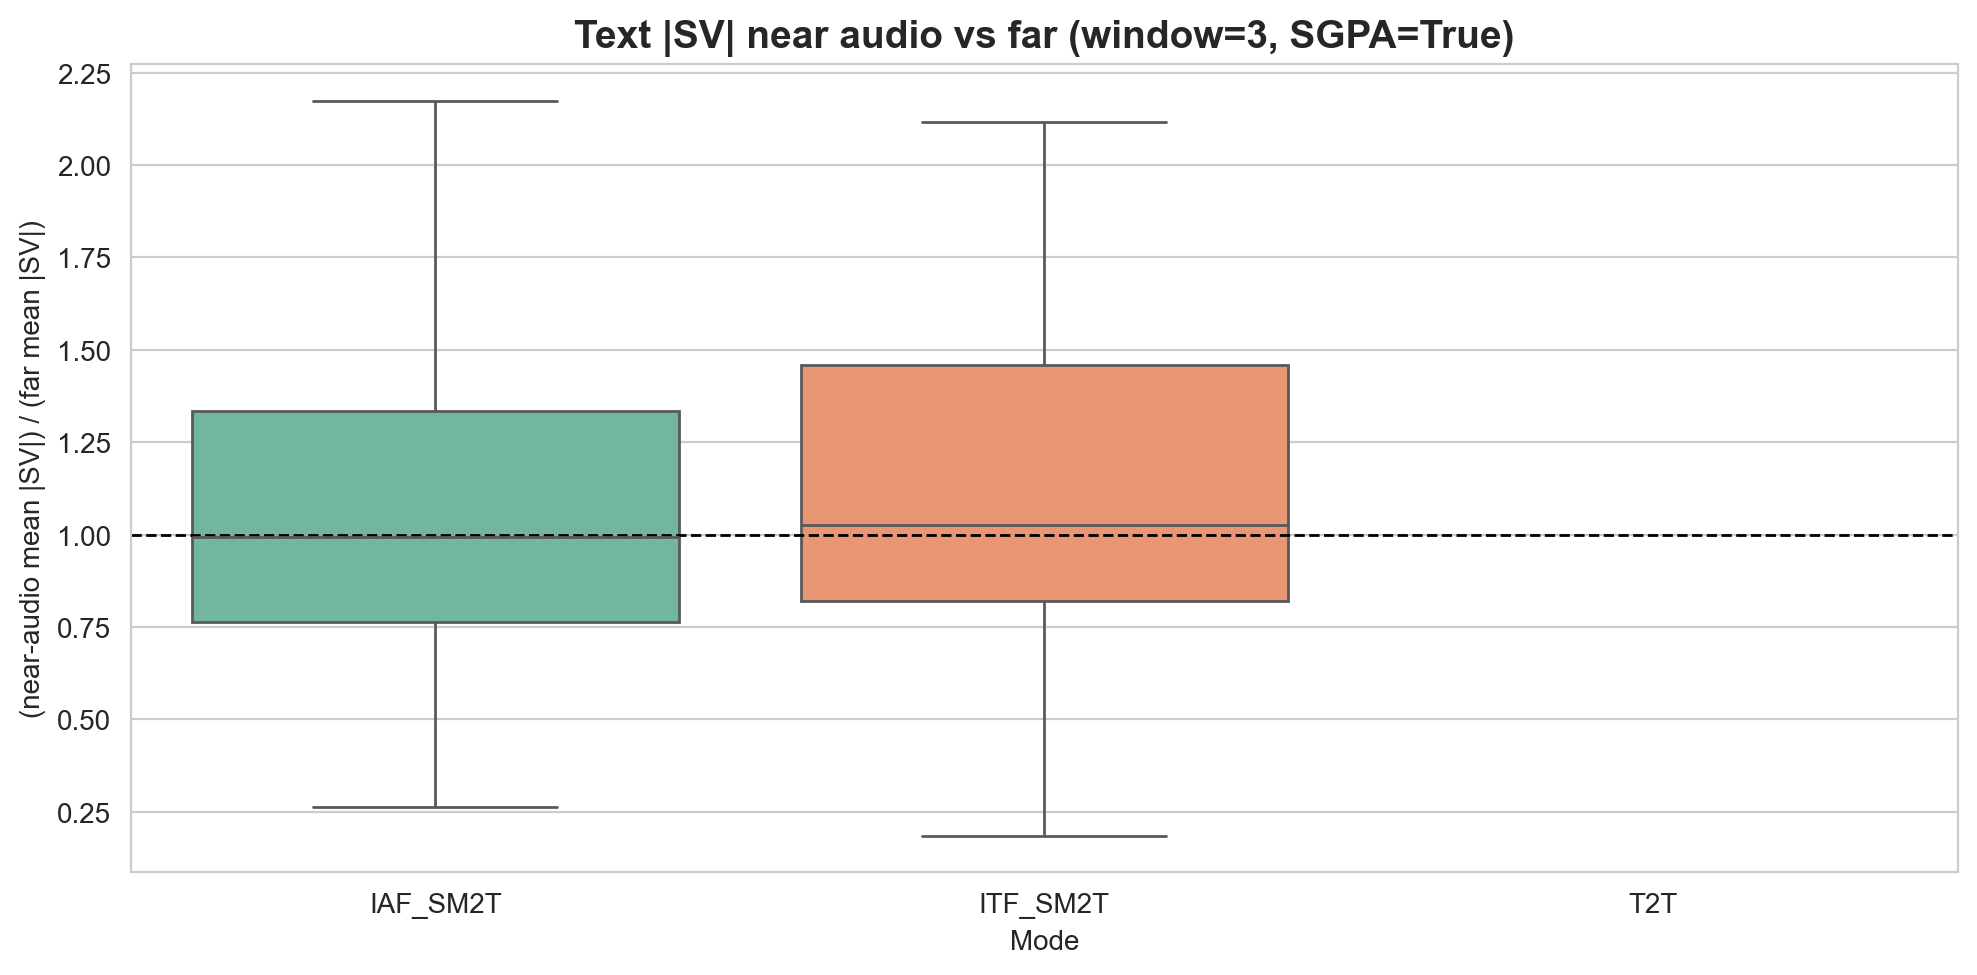

In [33]:
WINDOW = 3
t = results_df_sent.sort_values(["row_index", "mode", "id"]).reset_index(drop=True).copy()
t["audio_idx"] = (
    t.groupby(["row_index", "mode"])["is_audio"]
    .apply(lambda s: s.astype(int).rolling(2 * WINDOW + 1, center=True, min_periods=1).max())
    .reset_index(level=[0, 1], drop=True)
)
t["near_audio"] = t["audio_idx"] > 0

text_only = t[t["is_text"]].copy()
near_far = (
    text_only.groupby(["row_index", "mode"], as_index=False)
    .apply(
        lambda g: pd.Series(
            {
                "near_mean_abs_sv": g.loc[g["near_audio"], "abs_sv"].mean(),
                "far_mean_abs_sv": g.loc[~g["near_audio"], "abs_sv"].mean(),
            }
        )
    )
    .reset_index(drop=True)
)
near_far["near_over_far"] = near_far["near_mean_abs_sv"] / near_far["far_mean_abs_sv"]
near_far.to_csv(f"{STATS_DIR}/near_audio_ratio_by_sample.csv", index=False)

plt.figure(figsize=(10, 5))
sns.boxplot(data=near_far, x="mode", y="near_over_far", showfliers=False, palette="Set2")
plt.axhline(1.0, color="black", linewidth=1, linestyle="--")
plt.title(f"Text |SV| near audio vs far (window={WINDOW}, SGPA=True)", fontsize=14, fontweight="bold")
plt.xlabel("Mode")
plt.ylabel("(near-audio mean |SV|) / (far mean |SV|)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/near_audio_ratio.png", bbox_inches="tight", dpi=300)